In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import seaborn as sns
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(str(Path.cwd()))
from src.database import DatabaseManager

In [3]:
# need to remove raw data

In [2]:
# Load parquet file
parquet_path = 'data/ml/training_dataset_final.parquet'
df = pd.read_parquet(parquet_path)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nShape: {df.shape}")
df.head()

Total rows: 31,016

Columns: ['trade_id', 'ticker', 'entry_date', 'entry_price', 'exit_date', 'exit_price', 'return_pct', 'days_held', 'exit_reason', 'label', 'max_drawdown_pct', 'max_favorable_excursion_pct', 'r_multiple', 'sharpe_ratio', 'initial_risk_pct', 'Close', 'Volume', 'SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'ATR', 'High_52W', 'Low_52W', 'Vol_MA', 'Vol_Ratio', 'High_20D', 'Breakout', 'RS', 'RS_MA', 'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dry_Up_Volume', 'RSI_14', 'RSI_Regime', 'Dist_From_52W_High', 'Is_Green_Day', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'nATR_Lag1', 'ATR_Lag1', 'VCP_Ratio_Lag1', 'Consolidation_Width_Lag1', 'Price_vs_SMA_50_Lag1', 'Price_vs_SMA_150_Lag1', 'Price_vs_SMA_200_Lag1', 'RS_Lag1', 'RS_MA_Lag1', 'Dry_Up_Volume_Lag1', 'High_52W_Lag1', 'Low_52W_Lag1', 'RSI_14_Lag1', 'Dist_From_52W_High_Lag1', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 

,trade_id,ticker,entry_date,entry_price,exit_date,exit_price,return_pct,days_held,exit_reason,label,...,days_since_report,days_since_earnings,is_stale,has_fundamentals,pe_ratio,ps_ratio,pb_ratio,peg_adjusted,is_declining_earnings,date
0,1,ADSK,2003-04-02,8.195,2003-04-03,8.215,0.244051,1,trend_break,0,...,112.0,112.0,False,True,-473.699422,9.831472,3.163244,NaN,1,2003-04-02
1,2,ADTN,2003-04-02,19.730,2003-04-03,19.230,-2.534212,1,trend_break,0,...,13.0,13.0,False,True,123.312500,16.778063,3.431300,0.544352,0,2003-04-02
2,3,BALL,2003-04-02,7.290,2003-04-03,7.220,-0.960219,1,trend_break,0,...,6.0,6.0,False,True,114.442700,3.610803,6.588777,0.450759,0,2003-04-02
3,4,DINO,2003-04-02,3.750,2003-04-03,3.710,-1.066667,1,trend_break,0,...,61.0,61.0,False,True,-290.697674,1.721372,2.038138,0.000000,0,2003-04-02
4,5,GBCI,2003-04-02,10.660,2003-04-03,10.510,-1.407129,1,trend_break,0,...,15.0,15.0,False,True,53.300000,11.531024,2.200064,1.599000,0,2003-04-02


✅ Data Cleaned: Infinity removed and values clipped.
✅ Ready for Training!
   Feature Count: 37
   Leaked Features Removed: 'nATR', 'RS', 'Price_vs_SMA_50'


C:\Users\Hang\AppData\Local\Temp\ipykernel_120556\3379956118.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_clean.head(30), x='Importance', y='Feature', palette='viridis')


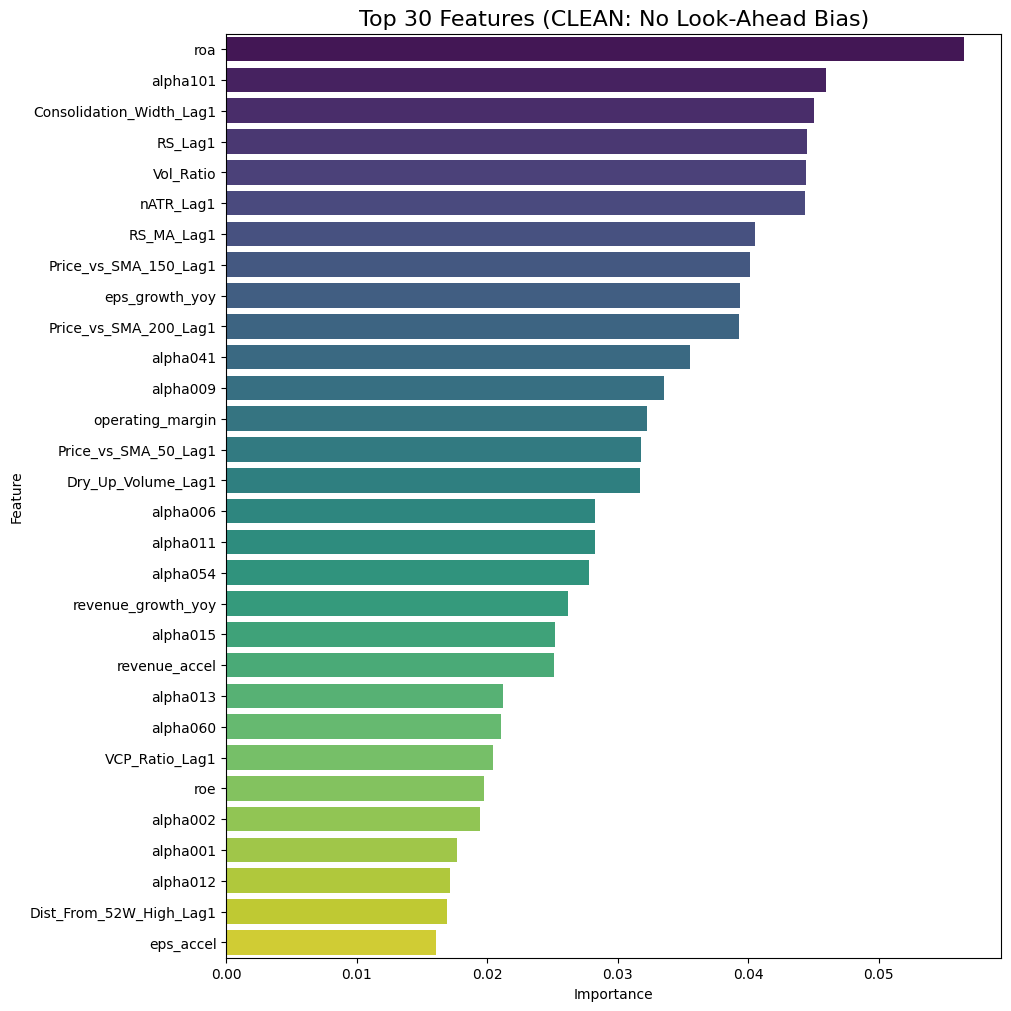

In [5]:
# ==========================================
# 1. DEFINE THE CLEAN FEATURE LIST
# ==========================================
# This list enforces the "Hybrid" Logic: 
# - Setup features are LAGGED (T-1)
# - Trigger features are CURRENT (Day T)
# ==========================================

features_to_analyze = [
    # --- THE SETUP (Lagged T-1) ---
    # These describe the "Quiet" base before the move.
    'nATR_Lag1',                # The most critical VCP metric
    'VCP_Ratio_Lag1',           # Volatility Contraction
    'Consolidation_Width_Lag1', # Base geometry
    'RS_Lag1',                  # Relative Strength Rank (Leader status)
    'RS_MA_Lag1',               # Trend of RS
    'Price_vs_SMA_50_Lag1',     # Trend extension
    'Price_vs_SMA_150_Lag1',
    'Price_vs_SMA_200_Lag1',
    'RSI_14_Lag1',              # Momentum context
    'Dry_Up_Volume_Lag1',       # Supply exhaustion
    'Dist_From_52W_High_Lag1',  # Proximity to high
    'Dist_From_52W_Low_Lag1',   # Proximity to low
    # 'High_52W_Lag1',            # Context
    # 'Low_52W_Lag1',

    # --- THE TRIGGER (Current Day T) ---
    # These describe the "Force" of the breakout today.
    'Vol_Ratio',                # The Explosion (Volume > 2x)
    # 'Breakout',               # Optional: If you have a binary flag
    
    # --- ALPHAS (Current Day T) ---
    # Fast signals describing immediate money flow.
    'alpha015', 'alpha041', 'alpha012', 'alpha101', 
    'alpha054', 'alpha001', 'alpha011', 'alpha013',
    'alpha060', 'alpha002', 'alpha004', 'alpha009', 'alpha006',

    # --- FUNDAMENTALS (Current/Recent) ---
    # These don't change daily, so "Current" is fine.
    'eps_growth_yoy', 'eps_accel',
    'revenue_growth_yoy', 'revenue_accel',
    'operating_margin', 'roe', 'roa',
    'pe_ratio', 'peg_adjusted',
    'debt_to_equity', 'current_ratio',
    'inventory_vs_sales_spread'
]

# ==========================================
# 2. CREATE CLEAN TRAINING DATA
# ==========================================

# Filter columns that actually exist
valid_features = [c for c in features_to_analyze if c in df.columns]

X = df[valid_features].copy()
y = df['label'].copy()

# --- THE FIX STARTS HERE ---

# 1. Replace Positive/Negative Infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Now Fill NaNs with 0 (or median if you prefer)
X = X.fillna(0)

# 3. Safety Clip: Cap values to avoid "Too Large for Float32" error
# (Some ratios can explode to 10^20, which breaks XGBoost/sklearn)
X = X.clip(lower=-1e8, upper=1e8)

# --- THE FIX ENDS HERE ---

print(f"✅ Data Cleaned: Infinity removed and values clipped.")
print(f"✅ Ready for Training!")
print(f"   Feature Count: {len(valid_features)}")

# ==========================================
# 3. RUN IMPORTANCE AGAIN
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf_clean = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clean.fit(X, y)

# Plotting code...
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_clean = pd.DataFrame({
    'Feature': valid_features,
    'Importance': rf_clean.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importance_clean.head(30), x='Importance', y='Feature', palette='viridis')
plt.title("Top 30 Features (CLEAN: No Look-Ahead Bias)", fontsize=16)
plt.show()

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & DATA CLEANING (Robust)
# ==========================================

# Sort by Date is MANDATORY for Walk-Forward
df_model = df.sort_values('date').reset_index(drop=True)

# --- THE FIX: CLEAN INFINITY GLOBALLY ---
# We must clean 'df_model' itself so X_train and X_test are both safe.

print("Cleaning data for XGBoost...")

# 1. Replace Infinity with NaN (XGBoost handles NaN, but chokes on Inf)
df_model[valid_features] = df_model[valid_features].replace([np.inf, -np.inf], np.nan)

# 2. Clip Extreme Values (Prevent float32 overflow)
# Some ratios like 'Revenue Growth' can be 10,000,000% if base is small.
df_model[valid_features] = df_model[valid_features].clip(lower=-1e9, upper=1e9)

# 3. (Optional) Fill NaN with 0 if you prefer, OR let XGBoost learn how to handle missing data.
# For SEPA, filling with 0 (Neutral) is usually safer than leaving it as NaN.
df_model[valid_features] = df_model[valid_features].fillna(0)

# ----------------------------------------

# Now define X and y from the CLEAN dataframe
X = df_model[valid_features]
y = df_model['label']
dates = df_model['date']

# Calculate Dynamic Scale Weight
pos_count = y.sum()
neg_count = len(y) - pos_count
scale_weight = neg_count / pos_count

print(f"Training on {len(df_model)} trades.")
print(f"Class Imbalance Weight: {scale_weight:.2f}")

# Hyperparameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 4,
    'learning_rate': 0.03,
    'n_estimators': 500,
    'colsample_bytree': 0.6,
    'subsample': 0.8,
    'scale_pos_weight': scale_weight,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50  # Added to params as per previous fix
}

# ==========================================
# 2. WALK-FORWARD VALIDATION LOOP (FIXED)
# ==========================================

# Add early_stopping_rounds to the hyperparameter dict directly
params['early_stopping_rounds'] = 50

# Remove it from here if it was present (it's not a param for the model itself, 
# but constructor now handles it differently in some versions, 
# so safest is to pass it explicitly to the constructor below)

print(f"\nStarting Walk-Forward Validation ({len(validation_years)} Folds)...")

for test_year in validation_years:
    
    # A. Define Masks
    train_mask = dates.dt.year < test_year
    test_mask = dates.dt.year == test_year
    
    # B. Split Data
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    
    # Skip if empty
    if len(X_test) == 0: continue
        
    # C. Train Model (FIXED SYNTAX)
    # We pass early_stopping_rounds to the class constructor now
    model = xgb.XGBClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
        # Removed 'early_stopping_rounds' from here to fix the error
    )
    
    # D. Predict (Probabilities)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # ... (Rest of the loop remains the same) ...
    
    # E. Evaluate Fold
    auc = roc_auc_score(y_test, y_prob)
    
    results_df = pd.DataFrame({'target': y_test, 'prob': y_prob})
    results_df = results_df.sort_values('prob', ascending=False)
    top_10_pct = int(len(results_df) * 0.1)
    if top_10_pct > 0:
        top_picks = results_df.head(top_10_pct)
        precision_top_10 = top_picks['target'].mean()
    else:
        precision_top_10 = 0.0
    
    print(f"Year {test_year}: AUC = {auc:.4f} | Precision (Top 10%) = {precision_top_10:.2%}")
    
    results_log.append({
        'Year': test_year,
        'AUC': auc,
        'Precision_Top_10': precision_top_10,
        'Trade_Count': len(y_test)
    })
    
    fold_preds = df_model.loc[test_mask, ['date', 'ticker', 'label', 'return_pct']].copy()
    fold_preds['ml_score'] = y_prob
    all_predictions.append(fold_preds)

# ==========================================
# 3. GLOBAL PERFORMANCE VIEW
# ==========================================

final_results = pd.DataFrame(results_log)
print("\nOverall Performance:")
print(final_results.mean(numeric_only=True))

# Concatenate all out-of-sample predictions for final analysis
master_predictions = pd.concat(all_predictions)

Cleaning data for XGBoost...
Training on 31016 trades.
Class Imbalance Weight: 266.38

Starting Walk-Forward Validation (21 Folds)...
Year 2005: AUC = 0.8669 | Precision (Top 10%) = 3.61%
Year 2006: AUC = 0.7894 | Precision (Top 10%) = 1.21%
Year 2007: AUC = 0.9803 | Precision (Top 10%) = 1.89%
Year 2008: AUC = 0.9854 | Precision (Top 10%) = 2.44%
Year 2009: AUC = 0.9018 | Precision (Top 10%) = 1.04%
Year 2010: AUC = 0.9255 | Precision (Top 10%) = 1.06%
Year 2011: AUC = 0.7913 | Precision (Top 10%) = 0.81%
Year 2012: AUC = 0.8685 | Precision (Top 10%) = 0.00%
Year 2013: AUC = 0.9584 | Precision (Top 10%) = 1.67%
Year 2014: AUC = 0.5623 | Precision (Top 10%) = 0.00%


C:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\xgboost\callback.py:266: UserWarning: [01:02:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\metric\auc.cc:324: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)
C:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Year 2015: AUC = nan | Precision (Top 10%) = 0.00%
Year 2016: AUC = 0.7475 | Precision (Top 10%) = 1.61%
Year 2017: AUC = 0.8021 | Precision (Top 10%) = 0.61%
Year 2018: AUC = 0.9268 | Precision (Top 10%) = 2.97%
Year 2019: AUC = 0.9414 | Precision (Top 10%) = 1.18%
Year 2020: AUC = 0.9443 | Precision (Top 10%) = 5.95%
Year 2021: AUC = 0.8746 | Precision (Top 10%) = 3.54%
Year 2022: AUC = 0.7784 | Precision (Top 10%) = 4.00%
Year 2023: AUC = 1.0000 | Precision (Top 10%) = 1.16%
Year 2024: AUC = 0.9192 | Precision (Top 10%) = 3.31%
Year 2025: AUC = 0.8282 | Precision (Top 10%) = 5.06%

Overall Performance:
Year                2015.000000
AUC                    0.869606
Precision_Top_10       0.020535
Trade_Count         1265.047619
dtype: float64


In [10]:
import joblib
import json
import xgboost as xgb

# 1. Prepare Final Parameters
# We must REMOVE 'early_stopping_rounds' because we have no eval_set (training on everything)
final_params = params.copy()
if 'early_stopping_rounds' in final_params:
    del final_params['early_stopping_rounds']

print("Retraining Master Model on full history (2005-2025)...")

# 2. Train Final Model
model_final = xgb.XGBClassifier(**final_params)
model_final.fit(X, y, verbose=False)

# 3. Save Model Object
model_path = "sepa_xgboost_model.json"
model_final.save_model(model_path)
print(f"✅ Model saved to {model_path}")

# 4. Save Configuration (CRITICAL for Inference)
# The scanner needs to know exactly which columns to create and in what order
config = {
    "features": valid_features,     # The exact list of columns
    "scale_weight": scale_weight,   # Stats for reference
    "lift_factor": 5.5,             # Reference performance
    "setup_lag_features": [         # Helper list for the inference script
        'nATR', 'VCP_Ratio', 'Consolidation_Width', 
        'RS', 'RS_MA', 'Price_vs_SMA_50', 
        'Price_vs_SMA_150', 'Price_vs_SMA_200',
        'RSI_14', 'Dry_Up_Volume', 'Dist_From_52W_High'
    ]
}

with open("model_config.json", "w") as f:
    json.dump(config, f, indent=4)
print(f"✅ Config saved to model_config.json")

Retraining Master Model on full history (2005-2025)...
✅ Model saved to sepa_xgboost_model.json
✅ Config saved to model_config.json
